# Exploración descriptiva: delitos reportados en Bucaramanga (2016-2022)

Análisis descriptivo previo al modelo. Usa `data/delitos_bucaramanga.csv` (recurso `x46e-abhz` de datos.gov.co,
generado con `python src/download_data.py`) y la limpieza de `src/prep.py`.

Este notebook **solo muestra agregados** (conteos y porcentajes); no imprime filas individuales de víctimas.

Contenido: 1) tamaño y limpieza · 2) tipología por año · 3) comuna · 4) día de la semana · 5) franja horaria ·
6) datos faltantes por año (incluye 2023) · 7) deriva de etiquetas · 8) conclusiones.

In [1]:
import json
import sys
import urllib.parse
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, str(Path("..") / "src"))
from prep import COLS, limpiar

DATA = Path("..") / "data" / "delitos_bucaramanga.csv"
if not DATA.exists():
    raise FileNotFoundError("Falta data/delitos_bucaramanga.csv. Generalo con: python src/download_data.py")

plt.rcParams.update({"figure.dpi": 80, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True})
pd.set_option("display.width", 160)

SHORT = {
    "DELITOS CONTRA EL PATRIMONIO ECONOMICO": "Patrimonio económico",
    "DELITOS CONTRA LA VIDA Y LA INTEGRIDAD PERSONAL": "Vida e integridad personal",
    "DELITOS CONTRA LA FAMILIA": "Familia",
    "DELITOS CONTRA LA LIBERTAD, INTEGRIDAD Y FORMACION SEXUALES": "Libertad e integridad sexual",
    "DELITOS CONTRA LA SEGURIDAD PUBLICA": "Seguridad pública",
}
ORDER = list(SHORT.values())
COLORS = dict(zip(ORDER, ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3"]))

## 1. Tamaño de los datos y limpieza

In [2]:
raw = pd.read_csv(DATA, low_memory=False)
raw.columns = COLS  # mismos nombres que usa src/prep.py (el orden de columnas del recurso es fijo)
n_columnas = raw.shape[1]
raw["anio"] = pd.to_datetime(raw["fecha_hecho"]).dt.year
raw["tip"] = raw["tipologia"].map(SHORT)

df, steps = limpiar(DATA)
df["tip"] = df["tipologia"].map(SHORT)

print(f"Filas en crudo: {len(raw):,} | columnas: {n_columnas} | años {raw['anio'].min()}-{raw['anio'].max()}")
print(f"Filas tras la limpieza de src/prep.py: {len(df):,} ({len(df) / len(raw) * 100:.1f} % del total)")
embudo = pd.DataFrame(steps, columns=["paso", "filas"])
embudo["descartadas"] = -embudo["filas"].diff().fillna(0).astype(int)
display(embudo)

Filas en crudo: 88,627 | columnas: 26 | años 2016-2022
Filas tras la limpieza de src/prep.py: 76,385 (86.2 % del total)


,paso,filas,descartadas
0,filas descargadas,88627,0
1,tras quitar duplicados,88617,10
2,armas con >=100 casos,88588,29
3,sin arma NO REPORTADO,88324,264
4,sin corregimientos,87398,926
5,sin barrios fuera de Bucaramanga,84848,2550
6,movil_agresor valido,84846,2
7,movil_victima valido,84835,11
8,sexo distinto de NO DISPONIBLE,76485,8350
9,"edad valida (sin NA, NO DISPONIBLE, 125)",76385,100


In [3]:
por_anio = pd.DataFrame({"crudo": raw.groupby("anio").size(), "limpio": df.groupby("anio").size()})
por_anio["% conservado"] = (por_anio["limpio"] / por_anio["crudo"] * 100).round(1)
display(por_anio)

,crudo,limpio,% conservado
anio,,,
2016,10770,9353,86.8
2017,11004,9210,83.7
2018,12479,10522,84.3
2019,12892,11226,87.1
2020,10363,9185,88.6
2021,15369,12987,84.5
2022,15750,13902,88.3


## 2. Tipología por año (datos limpios)

tip,Patrimonio económico,Vida e integridad personal,Familia,Libertad e integridad sexual,Seguridad pública
anio,,,,,
2016,4788,2248,1910,407,0
2017,5000,2124,1653,433,0
2018,6202,2164,1645,511,0
2019,7389,1892,1482,463,0
2020,5359,1524,1916,386,0
2021,6532,2825,1827,426,1377
2022,7826,2501,1498,383,1694


tip,Patrimonio económico,Vida e integridad personal,Familia,Libertad e integridad sexual,Seguridad pública
anio,,,,,
2016,51.2,24.0,20.4,4.4,0.0
2017,54.3,23.1,17.9,4.7,0.0
2018,58.9,20.6,15.6,4.9,0.0
2019,65.8,16.9,13.2,4.1,0.0
2020,58.3,16.6,20.9,4.2,0.0
2021,50.3,21.8,14.1,3.3,10.6
2022,56.3,18.0,10.8,2.8,12.2


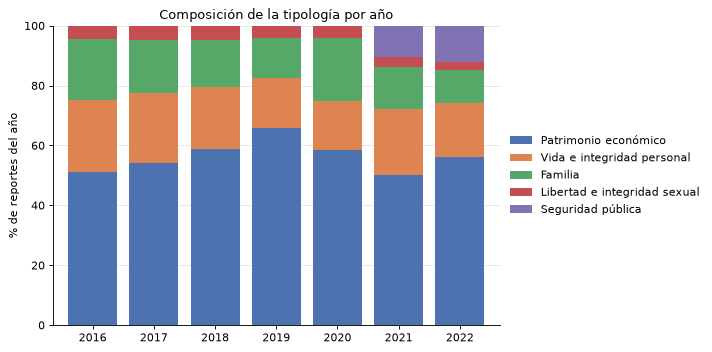

In [4]:
ct = pd.crosstab(df["anio"], df["tip"])[ORDER]
pct = ct.div(ct.sum(axis=1), axis=0) * 100
display(ct)
display(pct.round(1))

ax = pct.plot(kind="bar", stacked=True, figsize=(9, 4.5), color=[COLORS[c] for c in ORDER], width=0.8)
ax.set_ylabel("% de reportes del año"); ax.set_xlabel("")
ax.set_title("Composición de la tipología por año")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 3. Comuna

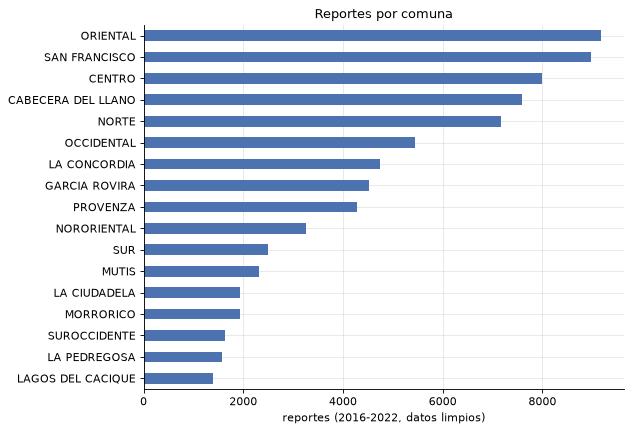

Las 5 comunas con más reportes concentran el 53.5 % del total.


,% de reportes
nom_comuna,
ORIENTAL,12.0
SAN FRANCISCO,11.7
CENTRO,10.5
CABECERA DEL LLANO,9.9
NORTE,9.4


In [5]:
por_comuna = df.groupby("nom_comuna").size().sort_values()
ax = por_comuna.plot(kind="barh", figsize=(8, 5.5), color="#4c72b0")
ax.set_xlabel("reportes (2016-2022, datos limpios)"); ax.set_ylabel("")
ax.set_title("Reportes por comuna")
plt.tight_layout(); plt.show()

share = (por_comuna / por_comuna.sum() * 100).sort_values(ascending=False)
print("Las 5 comunas con más reportes concentran el %.1f %% del total." % share.head(5).sum())
display(share.head(5).round(1).to_frame("% de reportes"))

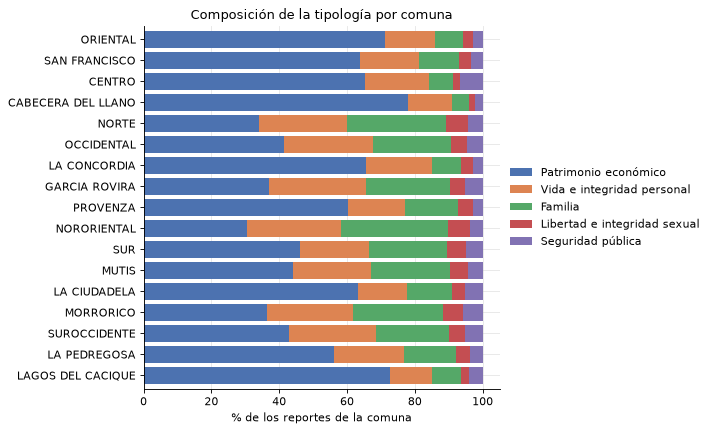

In [6]:
mix = (pd.crosstab(df["nom_comuna"], df["tip"], normalize="index")[ORDER] * 100).loc[por_comuna.index]
ax = mix.plot(kind="barh", stacked=True, figsize=(9, 5.5), color=[COLORS[c] for c in ORDER], width=0.8)
ax.set_xlabel("% de los reportes de la comuna"); ax.set_ylabel("")
ax.set_title("Composición de la tipología por comuna")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.tight_layout(); plt.show()

## 4. Día de la semana

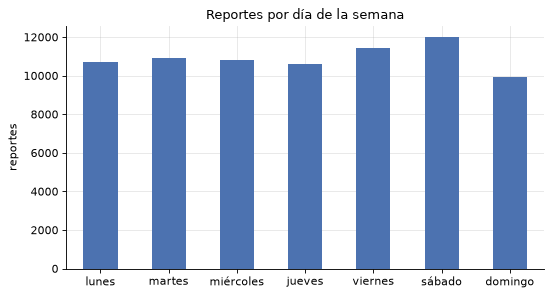

tip,Patrimonio económico,Vida e integridad personal,Familia,Libertad e integridad sexual,Seguridad pública
dia_nombre,,,,,
lunes,54.8,18.5,18.5,3.8,4.4
martes,58.6,17.1,16.6,3.5,4.2
miércoles,58.5,16.6,17.0,3.8,4.0
jueves,59.6,17.3,14.7,4.1,4.4
viernes,60.5,17.4,13.6,4.2,4.3
sábado,58.1,22.4,11.8,4.4,3.2
domingo,43.4,31.5,17.9,3.6,3.7


In [7]:
DIAS = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]
por_dia = df.groupby("dia_nombre").size().reindex(DIAS)
ax = por_dia.plot(kind="bar", figsize=(7, 3.8), color="#4c72b0")
ax.set_ylabel("reportes"); ax.set_xlabel(""); ax.set_title("Reportes por día de la semana")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

mix_dia = (pd.crosstab(df["dia_nombre"], df["tip"], normalize="index")[ORDER] * 100).reindex(DIAS)
display(mix_dia.round(1))

## 5. Franja horaria

,reportes,Patrimonio económico,Vida e integridad personal,Familia,Libertad e integridad sexual,Seguridad pública
rango_dia,,,,,,
MADRUGADA,10657,56.9,20.2,15.5,3.6,3.8
MAÑANA,23704,57.4,16.1,17.5,4.3,4.7
MEDIODIA,6508,64.6,17.8,11.8,2.8,3.0
TARDE,14922,55.8,20.5,14.0,4.5,5.2
ANOCHECER,8699,59.2,21.4,13.6,3.1,2.8
NOCHE,11895,48.3,27.2,17.6,4.1,2.8


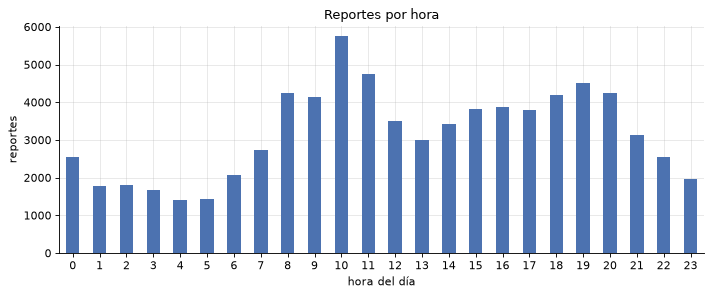

In [8]:
FRANJAS = ["MADRUGADA", "MAÑANA", "MEDIODIA", "TARDE", "ANOCHECER", "NOCHE"]
por_franja = df.groupby("rango_dia").size().reindex(FRANJAS)
mix_franja = (pd.crosstab(df["rango_dia"], df["tip"], normalize="index")[ORDER] * 100).reindex(FRANJAS)
display(pd.concat([por_franja.rename("reportes"), mix_franja.round(1)], axis=1))

df["hora"] = df["rango_horario"].str.split(":").str[0].astype(int)
por_hora = df.groupby("hora").size()
ax = por_hora.plot(kind="bar", figsize=(9, 3.8), color="#4c72b0")
ax.set_xlabel("hora del día"); ax.set_ylabel("reportes"); ax.set_title("Reportes por hora")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 6. Datos faltantes por año

Porcentaje de filas con `NO DISPONIBLE` (o nulo) en cada variable, sobre los datos **en crudo** de `data/` (2016-2022).

,sexo,edad,movil_victima,movil_agresor,clase_sitio,barrios_hecho
anio,,,,,,
2016,9.1,9.1,0.1,0.0,0.0,0.1
2017,11.2,11.4,0.0,0.0,0.0,0.3
2018,12.6,12.6,0.0,0.0,0.0,0.2
2019,10.0,10.0,0.0,0.0,0.0,0.3
2020,7.0,7.0,0.0,0.0,0.0,0.3
2021,9.4,10.9,0.0,0.0,0.0,2.7
2022,8.3,8.5,0.0,0.0,0.0,0.7


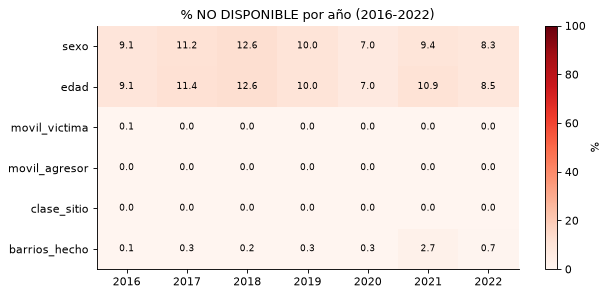

In [9]:
COLUMNAS = ["sexo", "edad", "movil_victima", "movil_agresor", "clase_sitio", "barrios_hecho"]
faltantes = pd.DataFrame({
    c: raw[c].astype(str).str.upper().isin(["NO DISPONIBLE", "NAN"]).groupby(raw["anio"]).mean() * 100
    for c in COLUMNAS
}).round(1)
display(faltantes)

fig, ax = plt.subplots(figsize=(8, 3.8))
im = ax.imshow(faltantes.T.values, cmap="Reds", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(faltantes.index))); ax.set_xticklabels(faltantes.index)
ax.set_yticks(range(len(COLUMNAS))); ax.set_yticklabels(COLUMNAS); ax.grid(False)
for i in range(len(COLUMNAS)):
    for j in range(len(faltantes.index)):
        ax.text(j, i, f"{faltantes.iloc[j, i]:.1f}", ha="center", va="center", fontsize=8)
ax.set_title("% NO DISPONIBLE por año (2016-2022)")
fig.colorbar(im, ax=ax, label="%"); plt.tight_layout(); plt.show()

### Qué pasa en 2023

`data/` no incluye 2023 a propósito (`src/download_data.py` filtra `fecha_hecho < '2023-01-01'`). Para mostrar por qué,
la celda siguiente consulta **solo conteos agregados** a la API (no descarga filas) para el año 2023 completo. Requiere internet.

Filas de 2023 en el recurso: 15,295
  movil_victima: 93.4 % NO DISPONIBLE
  edad: 83.4 % NO DISPONIBLE
  sexo: 4.6 % NO DISPONIBLE


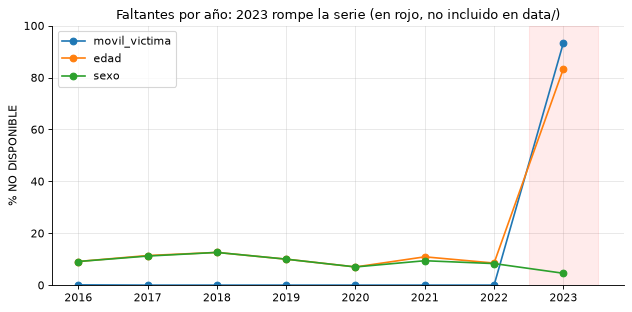

In [10]:
def soda_count(where):
    query = urllib.parse.urlencode({"$select": "count(*)", "$where": where})
    url = f"https://www.datos.gov.co/resource/x46e-abhz.json?{query}"
    with urllib.request.urlopen(url, timeout=60) as resp:
        return int(json.loads(resp.read())[0]["count"])

try:
    base = "fecha_hecho >= '2023-01-01' AND fecha_hecho < '2024-01-01'"
    total_2023 = soda_count(base)
    pct_2023 = {c: soda_count(f"{base} AND {c} = 'NO DISPONIBLE'") / total_2023 * 100 for c in ["movil_victima", "edad", "sexo"]}
    print(f"Filas de 2023 en el recurso: {total_2023:,}")
    for c, v in pct_2023.items():
        print(f"  {c}: {v:.1f} % NO DISPONIBLE")

    serie = faltantes[["movil_victima", "edad", "sexo"]].copy()
    serie.loc[2023] = [pct_2023["movil_victima"], pct_2023["edad"], pct_2023["sexo"]]
    ax = serie.plot(marker="o", figsize=(8, 4))
    ax.axvspan(2022.5, 2023.5, color="red", alpha=0.08)
    ax.set_ylabel("% NO DISPONIBLE"); ax.set_xlabel(""); ax.set_ylim(0, 100)
    ax.set_title("Faltantes por año: 2023 rompe la serie (en rojo, no incluido en data/)")
    plt.tight_layout(); plt.show()
except Exception as exc:  # sin conexion o API caida
    print(f"No se pudo consultar la API ({type(exc).__name__}); se omite la comparación con 2023.")

## 7. Deriva de etiquetas

Si la definición de las clases cambia con el tiempo, un modelo entrenado en el pasado no se puede evaluar bien en el futuro.

In [11]:
por_delito = pd.crosstab(raw["delito_solo"], raw["anio"])
por_delito["total"] = por_delito.sum(axis=1)
anios = [c for c in por_delito.columns if c != "total"]
incompletos = por_delito[(por_delito[anios] == 0).any(axis=1) & (por_delito["total"] >= 100)].sort_values("total", ascending=False)
print("Delitos con al menos 100 reportes que NO aparecen en todos los años (datos en crudo):")
display(incompletos)

seg = raw[raw["tip"] == "Seguridad pública"]
print("Contenido de la clase 'Seguridad pública' (datos en crudo, 2016-2022):")
display(seg["descripcion_conducta"].value_counts().to_frame("reportes"))

Delitos con al menos 100 reportes que NO aparecen en todos los años (datos en crudo):


anio,2016,2017,2018,2019,2020,2021,2022,total
delito_solo,,,,,,,,
AMENAZAS,0,0,0,0,0,1589,1776,3365
LESIONES CULPOSAS ( EN ACCIDENTE DE TRANSITO ),0,0,0,0,0,815,847,1662
HOMICIDIO CULPOSO ( EN ACCIDENTE DE TRÁNSITO),0,0,0,0,0,60,67,127


Contenido de la clase 'Seguridad pública' (datos en crudo, 2016-2022):


,reportes
descripcion_conducta,
ARTÍCULO 347. AMENAZAS,3365
ARTÍCULO 343. TERRORISMO,3
ARTÍCULO 350. INCENDIO,1


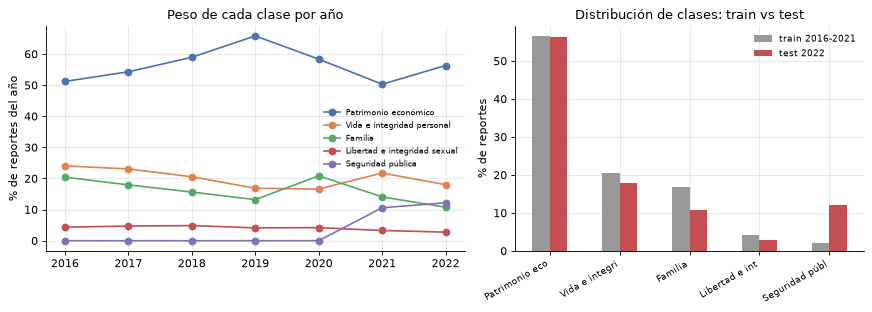

,train 2016-2021,test 2022
tip,,
Patrimonio económico,56.4,56.3
Vida e integridad personal,20.4,18.0
Familia,16.7,10.8
Libertad e integridad sexual,4.2,2.8
Seguridad pública,2.2,12.2


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.2, 1]})
pct[ORDER].plot(ax=axes[0], marker="o", color=[COLORS[c] for c in ORDER])
axes[0].set_ylabel("% de reportes del año"); axes[0].set_xlabel(""); axes[0].set_title("Peso de cada clase por año")
axes[0].legend(fontsize=7, frameon=False)

train_test = pd.DataFrame({
    "train 2016-2021": df[df["anio"] <= 2021]["tip"].value_counts(normalize=True) * 100,
    "test 2022": df[df["anio"] == 2022]["tip"].value_counts(normalize=True) * 100,
}).reindex(ORDER)
train_test.plot(kind="bar", ax=axes[1], color=["#999999", "#c44e52"])
axes[1].set_ylabel("% de reportes"); axes[1].set_xlabel(""); axes[1].set_title("Distribución de clases: train vs test")
axes[1].set_xticklabels([t.get_text()[:14] for t in axes[1].get_xticklabels()], rotation=30, ha="right", fontsize=8)
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()
display(train_test.round(1))

## 8. Conclusiones

- **Tamaño.** Hay 88.627 reportes de 2016 a 2022; la limpieza de `src/prep.py` conserva el 86,2 % (76.385). Los mayores descartes son `sexo` = `NO DISPONIBLE` (8.350 filas) y barrios fuera de Bucaramanga (2.550).
- **Composición.** *Patrimonio económico* es la clase mayoritaria todos los años (entre 50,3 % y 65,8 %). *Familia* baja de 20,4 % (2016) a 10,8 % (2022), con un pico en 2020 (20,9 %).
- **Comuna.** Cinco comunas (Oriental, San Francisco, Centro, Cabecera del Llano y Norte) reúnen el 53,5 % de los reportes.
- **Día y hora.** El domingo y la noche desplazan la mezcla hacia *Vida e integridad personal* (31,5 % el domingo y 27,2 % de noche) y reducen *Patrimonio económico* (43,4 % y 48,3 %). Son diferencias en la composición de lo **reportado**, no una medida de riesgo.
- **Datos faltantes.** `sexo` y `edad` tienen entre 7,0 % y 12,6 % de `NO DISPONIBLE` cada año de 2016 a 2022, sin cambio brusco; `movil_victima` casi no falta. En **2023** (15.295 filas según la API) falta el 93,4 % de `movil_victima` y el 83,4 % de `edad`: por eso `data/` no incluye 2023.
- **Deriva de etiquetas.** *Seguridad pública* no existe antes de 2021 y casi solo contiene `AMENAZAS` (3.365 de 3.369 reportes), un delito que no aparece en ningún año anterior. En 2021 también aparecen `LESIONES CULPOSAS` y `HOMICIDIO CULPOSO` en accidente de tránsito. Esa clase pasa de 2,2 % en train (2016-2021) a 12,2 % en test (2022): con un solo año de ejemplos previos, un modelo entrenado en 2016-2021 casi no puede aprenderla.
- **Alcance.** Todo lo anterior describe reportes registrados, no la incidencia real ni el riesgo de una persona o zona.